# 232 Group Project Part 3: Preprocessing & First Model Building and Evaluation

**Import Packages**

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, LongType, DoubleType, FloatType
from pyspark.sql.functions import col, count, length,countDistinct, broadcast, min as spark_min, max as spark_max,avg, stddev, approx_count_distinct
import requests
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import ArrayType, StringType
from pyspark.ml.feature import CountVectorizer, StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import PCA, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import numpy as np
import matplotlib.pyplot as plt

Matplotlib created a temporary cache directory at /scratch/siribe/job_49819080/matplotlib-g_0hsw4w because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


#### SDSC Expanse Environment Setup

8 total cores and 128 GB total memory, reserving 2 GB for the Spark driver. Executor instances = 8 - 1 = 7. Executor memory = (128 - 2) / 7 = 18 GB per executor. Spark is configured with 7 executor instances and 18 GB executor memory.

Calculated executer memory is ~17.7GB but we reduced it to 16 GB and allocated 2 GB memory overhead per executor to prevent memory exhaustion during heavy operations.

In [2]:
total_cores = 12
total_memory_gb = 192
driver_memory_gb = 4   

executor_instances = total_cores - 1
raw_executor_memory = (total_memory_gb - driver_memory_gb) / executor_instances

executor_memory_gb = 16
executor_overhead_gb = 2

print(f"Executor instances = {executor_instances}")
print(f"Raw executor memory = {raw_executor_memory:.2f} GB")
print(f"Configured executor memory = {executor_memory_gb} GB (+{executor_overhead_gb} GB overhead)")

spark = (
    SparkSession.builder
    .appName("MusicBrainz")
    .config("spark.driver.memory", f"{driver_memory_gb}g")
    .config("spark.executor.instances", executor_instances)
    .config("spark.executor.memory", f"{executor_memory_gb}g")
    .config("spark.executor.memoryOverhead", f"{executor_overhead_gb}g")
    .config("spark.sql.shuffle.partitions", executor_instances * total_cores)
    .getOrCreate()
)

sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

response = requests.get(url)
executors = response.json()

spark_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spark_df['maxMemory_GB'] = (spark_df['maxMemory'] / (1024**3)).round(2)
spark_df

Executor instances = 11
Raw executor memory = 17.09 GB
Configured executor memory = 16 GB (+2 GB overhead)


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,2388236697,0,True,2.22


### 1. Complete Preprocessing Using Spark

**Define Variables**

In [3]:
MBDUMP = "/expanse/lustre/projects/uci157/rwheaton1/mbdump"

In [4]:
def peek(df, n=20):
    return display(df.limit(n).toPandas())

**Define Schemas**

In [5]:
artist_schema = StructType([
    StructField("id",               IntegerType(),   True),
    StructField("gid",              StringType(),    True),
    StructField("name",             StringType(),    True),
    StructField("sort_name",        StringType(),    True),
    StructField("begin_date_year",  IntegerType(),   True),
    StructField("begin_date_month", IntegerType(),   True),
    StructField("begin_date_day",   IntegerType(),   True),
    StructField("end_date_year",    IntegerType(),   True),
    StructField("end_date_month",   IntegerType(),   True),
    StructField("end_date_day",     IntegerType(),   True),
    StructField("type",             IntegerType(),   True),
    StructField("area",             IntegerType(),   True),
    StructField("gender",           IntegerType(),   True),
    StructField("comment",          StringType(),    True),
    StructField("edits_pending",    IntegerType(),   True),
    StructField("last_updated",     StringType(),    True),
    StructField("ended",            StringType(),    True),
    StructField("begin_area",       IntegerType(),   True),
    StructField("end_area",         IntegerType(),   True),
])
instrument_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
    StructField("comment",       StringType(),  True),
    StructField("description",   StringType(),  True),
])
label_schema = StructType([
    StructField("id",                IntegerType(), True),
    StructField("gid",               StringType(),  True),
    StructField("name",              StringType(),  True),
    StructField("begin_date_year",   IntegerType(), True),
    StructField("begin_date_month",  IntegerType(), True),
    StructField("begin_date_day",    IntegerType(), True),
    StructField("end_date_year",     IntegerType(), True),
    StructField("end_date_month",    IntegerType(), True),
    StructField("end_date_day",      IntegerType(), True),
    StructField("label_code",        IntegerType(), True),
    StructField("type",              IntegerType(), True),
    StructField("area",              IntegerType(), True),
    StructField("comment",           StringType(),  True),
    StructField("edits_pending",     IntegerType(), True),
    StructField("last_updated",      StringType(),  True),
    StructField("ended",             StringType(),  True),
])
genre_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
area_schema = StructType([
    StructField("id",               IntegerType(), True),
    StructField("gid",              StringType(),  True),
    StructField("name",             StringType(),  True),
    StructField("type",             IntegerType(), True),
    StructField("edits_pending",    IntegerType(), True),
    StructField("last_updated",     StringType(),  True),
    StructField("begin_date_year",  IntegerType(), True),
    StructField("begin_date_month", IntegerType(), True),
    StructField("begin_date_day",   IntegerType(), True),
    StructField("end_date_year",    IntegerType(), True),
    StructField("end_date_month",   IntegerType(), True),
    StructField("end_date_day",     IntegerType(), True),
    StructField("ended",            StringType(),  True),
    StructField("comment",          StringType(),  True),
])
tag_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("ref_count",     IntegerType(), True),
])
gender_schema = StructType([
    StructField("id",   IntegerType(), True),
    StructField("name", StringType(),  True),
])
release_group_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("title",         StringType(),  True),
    StructField("artist_credit", IntegerType(), True),
    StructField("type",          IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
l_artist_label_schema = StructType([
    StructField("id",             IntegerType(), True),
    StructField("link",           IntegerType(), True),
    StructField("entity0",        IntegerType(), True),  # artist
    StructField("entity1",        IntegerType(), True),  # label
    StructField("edits_pending",  IntegerType(), True),
    StructField("last_updated",   StringType(),  True),
    StructField("link_order",     IntegerType(), True),
    StructField("entity0_credit", StringType(),  True),
    StructField("entity1_credit", StringType(),  True),
])
l_artist_release_group_schema = StructType([
    StructField("id",             IntegerType(), True),
    StructField("link",           IntegerType(), True),
    StructField("entity0",        IntegerType(), True),  # artist
    StructField("entity1",        IntegerType(), True),  # release_group
    StructField("edits_pending",  IntegerType(), True),
    StructField("last_updated",   StringType(),  True),
    StructField("link_order",     IntegerType(), True),
    StructField("entity0_credit", StringType(),  True),
    StructField("entity1_credit", StringType(),  True),
])
label_tag_schema = StructType([
    StructField("label",        IntegerType(), True),
    StructField("tag",          IntegerType(), True),
    StructField("count",        IntegerType(), True),
    StructField("last_updated", StringType(),  True),
])
l_artist_genre_schema = StructType([
    StructField("id",             IntegerType(), True),
    StructField("link",           IntegerType(), True),
    StructField("entity0",        IntegerType(), True),  # artist
    StructField("entity1",        IntegerType(), True),  # genre
    StructField("edits_pending",  IntegerType(), True),
    StructField("last_updated",   StringType(),  True),
    StructField("link_order",     IntegerType(), True),
    StructField("entity0_credit", StringType(),  True),
    StructField("entity1_credit", StringType(),  True),
])
l_artist_artist_schema = StructType([
    StructField("id",      IntegerType(), True),
    StructField("link",    IntegerType(), True),
    StructField("entity0", IntegerType(), True),
    StructField("entity1", IntegerType(), True),
])
release_group_tag_schema = StructType([
    StructField("release_group", IntegerType(), True),
    StructField("tag",           IntegerType(), True),
    StructField("count",         IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
artist_tag_schema = StructType([
    StructField("artist",       IntegerType(), True),
    StructField("tag",          IntegerType(), True),
    StructField("count",        IntegerType(), True),
    StructField("last_updated", StringType(),  True),
])
artist_credit_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("artist_count",  IntegerType(), True),
    StructField("ref_count",     IntegerType(), True),
    StructField("created",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("gid",           StringType(),  True),
])
artist_credit_name_schema = StructType([
    StructField("artist_credit", IntegerType(), True),
    StructField("position",      IntegerType(), True),
    StructField("artist",        IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("join_phrase",   StringType(),  True),
])
l_artist_instrument_schema = StructType([
    StructField("id",             IntegerType(), True),
    StructField("link",           IntegerType(), True),
    StructField("entity0",        IntegerType(), True),  # artist
    StructField("entity1",        IntegerType(), True),  # instrument
    StructField("edits_pending",  IntegerType(), True),
    StructField("last_updated",   StringType(),  True),
    StructField("link_order",     IntegerType(), True),
    StructField("entity0_credit", StringType(),  True),
    StructField("entity1_credit", StringType(),  True),
])
link_schema = StructType([
    StructField("id",                IntegerType(), True),
    StructField("link_type",         IntegerType(), True),
    StructField("begin_date_year",   IntegerType(), True),
    StructField("begin_date_month",  IntegerType(), True),
    StructField("begin_date_day",    IntegerType(), True),
    StructField("end_date_year",     IntegerType(), True),
    StructField("end_date_month",    IntegerType(), True),
    StructField("end_date_day",      IntegerType(), True),
    StructField("attribute_count",   IntegerType(), True),
    StructField("created",           StringType(),  True),
    StructField("ended",             StringType(),  True),
])
link_type_schema = StructType([
    StructField("id",                  IntegerType(), True),
    StructField("parent",              IntegerType(), True),
    StructField("child_order",         IntegerType(), True),
    StructField("gid",                 StringType(),  True),
    StructField("entity_type0",        StringType(),  True),
    StructField("entity_type1",        StringType(),  True),
    StructField("name",                StringType(),  True),
    StructField("description",         StringType(),  True),
    StructField("link_phrase",         StringType(),  True),
    StructField("reverse_link_phrase", StringType(),  True),
    StructField("long_link_phrase",    StringType(),  True),
    StructField("last_updated",        StringType(),  True),
    StructField("is_deprecated",       StringType(),  True),
    StructField("has_dates",           StringType(),  True),
    StructField("attribute_count",     IntegerType(), True),
    StructField("priority",            IntegerType(), True),
])
release_schema = StructType([
    StructField("id",              IntegerType(), True),
    StructField("gid",             StringType(),  True),
    StructField("name",            StringType(),  True),
    StructField("artist_credit",   IntegerType(), True),
    StructField("release_group",   IntegerType(), True),
    StructField("status",          IntegerType(), True),
    StructField("packaging",       IntegerType(), True),
    StructField("language",        IntegerType(), True),
    StructField("script",          IntegerType(), True),
    StructField("barcode",         StringType(),  True),
    StructField("comment",         StringType(),  True),
    StructField("edits_pending",   IntegerType(), True),
    StructField("quality",         IntegerType(), True),
    StructField("last_updated",    StringType(),  True),
])
release_label_schema = StructType([
    StructField("id",             IntegerType(), True),
    StructField("release",        IntegerType(), True),
    StructField("label",          IntegerType(), True),
    StructField("catalog_number", StringType(),  True),
    StructField("last_updated",   StringType(),  True),
])

schemas = {
    "artist": artist_schema,
    "instrument": instrument_schema,
    "label": label_schema,
    "genre": genre_schema,
    "area": area_schema,
    "tag": tag_schema,
    "gender": gender_schema,
    "release_group": release_group_schema,
    "l_artist_label": l_artist_label_schema,
    "l_artist_release_group": l_artist_release_group_schema,
    "label_tag": label_tag_schema,
    "l_artist_genre": l_artist_genre_schema,
    "l_artist_artist": l_artist_artist_schema,
    "release_group_tag": release_group_tag_schema,
    "artist_tag": artist_tag_schema,
    "artist_credit": artist_credit_schema,
    "artist_credit_name": artist_credit_name_schema,
    "l_artist_instrument": l_artist_instrument_schema,
    "link": link_schema,
    "link_type": link_type_schema,
    "release": release_schema,
    "release_label": release_label_schema,
}

**Table Details**

In [6]:
dfs = {}

for table_name, schema in schemas.items():
    print(f"\n==============================")
    print(f"Loading table: {table_name}")
    print(f"==============================")

    df = (
        spark.read
        .option("sep", "\t")
        .option("nullValue", r"\N")
        .option("header", "false")
        .option("quote", "")
        .option("escape", "")
        .schema(schema)
        .csv(f"{MBDUMP}/{table_name}")
    )

    dfs[table_name] = df
    
    row_count = df.count()
    print(f"Total {table_name} rows: {row_count}")
    duplicate_count = row_count - df.dropDuplicates().count()
    print(f"Duplicate rows in {table_name}: {duplicate_count}")

    print("=== SCHEMA ===")
    df.printSchema()

    print("=== PEEK ===")
    peek(df)


Loading table: artist
Total artist rows: 2853154
Duplicate rows in artist: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- sort_name: string (nullable = true)
 |-- begin_date_year: integer (nullable = true)
 |-- begin_date_month: integer (nullable = true)
 |-- begin_date_day: integer (nullable = true)
 |-- end_date_year: integer (nullable = true)
 |-- end_date_month: integer (nullable = true)
 |-- end_date_day: integer (nullable = true)
 |-- type: integer (nullable = true)
 |-- area: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- comment: string (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- ended: string (nullable = true)
 |-- begin_area: integer (nullable = true)
 |-- end_area: integer (nullable = true)

=== PEEK ===


,id,gid,name,sort_name,begin_date_year,begin_date_month,begin_date_day,end_date_year,end_date_month,end_date_day,type,area,gender,comment,edits_pending,last_updated,ended,begin_area,end_area
0,2252039,fadeb38c-833f-40bc-9d8c-a6383b38b1be,Доктор Сатана,Доктор Сатана,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2021-11-23 07:08:52.479537+00,f,NaN,NaN
1,371203,49add228-eac5-4de8-836c-d75cde7369c3,Pete Moutso,"Moutso, Pete",NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,None,0,None,f,NaN,NaN
2,3087346,dfdce491-133d-4e9f-9e48-795587e181b0,UNlT,UNlT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2025-09-14 23:53:28.004798+00,f,NaN,NaN
3,2851271,165a49a0-2b3b-4078-a3c1-905afdc07c0a,Babyglock,Babyglock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2024-10-19 03:33:55.474151+00,f,NaN,NaN
4,145773,7b4a548e-a01a-49b7-82e7-b49efeb9732c,Aric Leavitt,"Leavitt, Aric",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,None,f,NaN,NaN
5,1076328,60aca66f-e91a-4cb5-9308-b6e293cd833e,Fonograff,Fonograff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2014-01-10 16:25:20.992213+00,f,NaN,NaN
6,1172876,3e1bd546-d2a7-49cb-b38d-d70904a1d719,Al Street,"Street, Al",NaN,NaN,NaN,NaN,NaN,NaN,1.0,222.0,1.0,None,0,2014-11-23 14:07:19.782509+00,f,NaN,NaN
7,220155,df120895-f6c6-4a66-b9cf-73350f0beb61,Love .45,Love .45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,None,f,NaN,NaN
8,618464,c14f8d3f-ee81-416f-800f-8eff7e77a2e1,Sintellect,Sintellect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,2009-05-23 09:41:53.269195+00,f,NaN,NaN
9,285714,b68a3969-319a-462f-942b-cd35581414fc,Evie Tamala,Evie Tamala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,None,f,NaN,NaN



Loading table: instrument
Total instrument rows: 1056
Duplicate rows in instrument: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: integer (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- comment: string (nullable = true)
 |-- description: string (nullable = true)

=== PEEK ===


,id,gid,name,type,edits_pending,last_updated,comment,description
0,687,c1dbb66d-2356-417a-81ad-f688fee33257,guitarrón mexicano,2,0,2015-02-15 07:32:32.570132+00,None,The guitarrón mexicano is a very large and dee...
1,695,2474c241-d267-433a-a404-688b13c51d11,jouhikko,2,0,2015-02-25 19:47:04.610414+00,None,"The jouhikko is a traditional, 2 or 3 stringed..."
2,701,c0cc863c-ea65-4b8a-b365-28b81b72d846,friction idiophone,3,0,2015-02-26 10:28:49.766548+00,None,Friction idiophones are idiophones where the s...
3,706,5f9bb15a-738f-48bb-8676-55e62547726f,doshpuluur,2,0,2015-02-28 00:15:24.010482+00,None,The doshpuluur is a long-necked Tuvan lute.
4,707,9bae90ea-9729-4c30-bd3e-f8319cdf4051,igil,2,0,2015-02-28 23:39:39.01131+00,None,The igil is a Tuvan bowed string instrument wi...
5,712,c1d76a22-ab32-45af-be76-f3abd1eb2b2a,saw sam sai,2,0,2015-03-01 12:00:44.315438+00,None,The saw sam sai is a three-stringed bowed inst...
6,1003,50ae3eb1-0034-4a34-8367-aff6c30dee9a,gendèr panerus,3,0,2019-11-11 19:35:36.39114+00,Higest pitch metallophone used in Javanese gam...,"Used for simple ornamentation, it has thick sm..."
7,684,4e22ddb3-6908-4a5f-a9ae-b8a7440f6c7c,nabal,1,0,2026-02-19 21:37:08.325951+00,Korean straight brass horn,"Used in traditional music, it's long and strai..."
8,732,d3667988-a354-4fc4-9c1e-9baea9a43c06,bass oboe,1,0,2015-03-04 11:26:51.888966+00,None,The bass oboe is a double reed woodwind instru...
9,734,2ab4c035-374a-4188-bb7a-81c2558254f7,krar,2,0,2015-03-06 03:22:56.003792+00,None,The krar is a five or six-stringed bowl-shaped...



Loading table: label
Total label rows: 334811
Duplicate rows in label: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- begin_date_year: integer (nullable = true)
 |-- begin_date_month: integer (nullable = true)
 |-- begin_date_day: integer (nullable = true)
 |-- end_date_year: integer (nullable = true)
 |-- end_date_month: integer (nullable = true)
 |-- end_date_day: integer (nullable = true)
 |-- label_code: integer (nullable = true)
 |-- type: integer (nullable = true)
 |-- area: integer (nullable = true)
 |-- comment: string (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- ended: string (nullable = true)

=== PEEK ===


...

,id,parent,child_order,gid,entity_type0,entity_type1,name,description,link_phrase,reverse_link_phrase,long_link_phrase,last_updated,is_deprecated,has_dates,attribute_count,priority
0,12,NaN,0,38278b3b-30e6-304c-b0db-5ba701eb0268,release_group,release_group,covers and versions,None,covers or other versions,covers or other versions,covers and versions,2014-05-18 09:46:23.72719+00,f,f,0,0
1,735,NaN,0,12678b88-1adb-3536-890e-9b39b9a14b2d,instrument,instrument,children,None,children,child of,has child,2014-05-18 10:41:05.403719+00,f,f,0,0
2,870,784.0,0,4789521b-57b9-4689-9644-46de63190f66,series,url,soundcloud,"This links a series (most commonly, but not ne...",SoundCloud,SoundCloud page for,has a SoundCloud page at,2015-12-16 11:53:10.160133+00,f,t,0,0
3,957,NaN,2,a6874915-b6a3-42ef-82af-6ba800d1e940,label,url,get the music,None,get the music,get the music,get the music,2018-05-18 10:37:46.114037+00,f,f,0,0
4,227,234.0,0,451076df-61cf-46ab-9921-555cab2f050d,recording,recording,DJ-mix,"This is used to link a <a href=""/doc/Mix_Termi...",DJ-mix of,DJ-mixes,is a DJ-mix of,2021-02-02 10:14:29.683106+00,f,t,0,0
5,754,188.0,0,8147b6a2-ad14-4ce7-8f0a-697f9a31f68f,artist,url,IMSLP,"This links an artist to its page in <a href=""h...",IMSLP,IMSLP page for,has an IMSLP page at,2020-02-17 13:17:20.780295+00,f,t,0,0
6,921,NaN,1,9900c8c5-9844-4f10-8403-23aabafd913c,url,work,work list entry,This link points to a page for a particular wo...,work list entry for,work list entry,{entity1} has a work list entry at {entity0},2019-08-14 15:57:32.555087+00,f,t,0,0
7,2,4.0,0,fc399d47-23a7-4c28-bfcf-0607a562b644,release,release,transl-tracklisting,This indicates that one release is identical t...,transliterated/translated track listings,transliterated/translated track listing of,is the original for the transliterated/transla...,2015-07-17 08:53:57.281375+00,f,f,0,0
8,154,157.0,1,83f72956-2007-4bca-8a97-0ae539cca99d,artist,recording,samples from artist,Indicates that the recording contains samples ...,produced material that was {additional:additio...,contains {additional} samples by,{entity1} contains {additional} samples by {en...,2015-11-05 16:48:09.775478+00,f,t,1,0
9,871,54.0,3,4db37fec-eb67-45d3-b4fa-148a68135fbb,artist,release,translator,Indicates the person who translated the lyrics...,translated,{additional} translator,{additional:additionally} translated,2015-08-18 22:41:18.220935+00,f,t,1,0



Loading table: release
Total release rows: 5444000
Duplicate rows in release: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- gid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- artist_credit: integer (nullable = true)
 |-- release_group: integer (nullable = true)
 |-- status: integer (nullable = true)
 |-- packaging: integer (nullable = true)
 |-- language: integer (nullable = true)
 |-- script: integer (nullable = true)
 |-- barcode: string (nullable = true)
 |-- comment: string (nullable = true)
 |-- edits_pending: integer (nullable = true)
 |-- quality: integer (nullable = true)
 |-- last_updated: string (nullable = true)

=== PEEK ===


,id,gid,name,artist_credit,release_group,status,packaging,language,script,barcode,comment,edits_pending,quality,last_updated
0,9,425cf29a-1490-43ab-abfa-7b17a2cec351,A Sorta Fairytale,60,896742,1.0,NaN,120.0,28.0,None,None,0,-1,2010-03-30 19:04:18.144351+00
1,10,a96e1d03-e685-3627-8cba-f5b96be7158f,A Sorta Fairytale,60,896742,1.0,NaN,120.0,28.0,None,None,0,-1,2010-03-30 19:04:18.144351+00
2,3257193,6072a02d-e3cb-4f6a-b29c-526e8a0c4873,Kriminaltango et al,1,2823308,NaN,1.0,NaN,NaN,None,None,0,-1,2021-11-23 07:15:35.352498+00
3,12,9660928f-7cd8-4fef-852d-5599dc4ad3ec,Silent All These Years,60,104189,1.0,NaN,120.0,28.0,None,None,0,-1,None
4,26,dd245091-b21e-48a3-b59a-f9b8ed8a0469,Demons,20211,94299,1.0,NaN,120.0,28.0,None,None,0,-1,2009-05-25 10:03:19.927951+00
5,49,bc9afecd-685e-482c-9412-27f2d267b1dd,Out Spaced,20211,94125,1.0,NaN,284.0,28.0,5017556902295,None,0,-1,None
6,372235,71d9b457-08d6-4fa2-b932-ff56f03f9e70,Open Up Your Mind,50426,596076,1.0,1.0,120.0,28.0,724387771925,None,0,-1,2011-07-13 00:54:04.7202+00
7,2356295,8a73db92-1396-4969-a938-0dab0ca30b97,Augusta Taurinorum,353467,2113953,1.0,NaN,120.0,28.0,None,None,0,-1,2019-02-21 19:04:24.624662+00
8,1088433,028f5506-9f4f-46c0-931e-186d1903788c,Talking in the Streets,876468,1106241,1.0,1.0,120.0,28.0,886978945624,None,0,-1,2011-11-14 10:00:25.079777+00
9,2415264,d819962a-5bfa-463f-9b92-fd5bb4d8584f,Café Tacuba,11630,123217,1.0,NaN,393.0,28.0,090317724126,None,0,-1,2019-05-13 18:57:43.836154+00



Loading table: release_label
Total release_label rows: 4675976
Duplicate rows in release_label: 0
=== SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- release: integer (nullable = true)
 |-- label: integer (nullable = true)
 |-- catalog_number: string (nullable = true)
 |-- last_updated: string (nullable = true)

=== PEEK ===


,id,release,label,catalog_number,last_updated
0,3262571,3886289,3267,[none],2023-05-15 17:55:01.237161+00
1,754743,1219491,72973,None,2012-11-13 13:25:10.730748+00
2,5357,5,4934,422-828 553-2,2011-05-16 15:59:00.785958+00
3,481398,187,83127,D101335,2014-10-13 17:48:25.709377+00
4,3714264,4391108,3267,None,2024-05-13 19:56:21.283593+00
5,379,14,14486,ZK 52959,2011-05-16 15:59:00.785958+00
6,2359550,2893262,4338,None,2020-11-27 17:01:05.566757+00
7,33450,16,951,CRESCD235,2011-05-16 15:59:00.785958+00
8,33452,17,951,CRESCD243,2011-05-16 15:59:00.785958+00
9,33444,18,951,CRESCD 252,2011-05-16 15:59:00.785958+00


**Explore and Summarize Columns**

The below section creates a profiling loop that classifies columns by their role and then summarizes them. The MusicBrainz dataset has a lot of IDs and relationship table columns so we need to sift through it and figure out which numeric columns should be summarized like a continuous variable verses an ID. The loop reports nulls, distinct counts, duplicates, categorical frequencies, numeric summaries, and foreign key uniqueness depending on the column type. 

We started by idetifying the primary keys, global ID, forgein key, date part, boolean, text descriptor and count measure clumns for each of the tables we chose.

We then created the function __get_column_role__ that classifies a given column's role/data type. This function is executed in the for loop which loops through each table's columns to summarize them based on their role which was assigned in the __get_column_role__ function. 

- ID (or id-ish) columns like id, gid, entity0, and entity1, the loop returns missing values, distinct counts, and if foreign keys match the referenced table (not sure if this is actually working how we want it to so take this part with a grain of salt). Not showing frequency distributions bc most ID values are unique and a top 10 count table wouldnt be value add

- Categorical columns are summarized using value counts and percentages to show which values are most common and whether the distribution is balanced or skewed

- Numeric/count columns are summarized with count, mean, standard deviation, min, quartiles, and max

- High-cardinality text columns, like names or UUIDs, get summarized with distinct counts and length stats instead of value counts bc there are way too many unique values

In [7]:
primary_key_cols = {"id"}
global_id_cols = {"gid"}
foreign_key_map = {
    "artist": {
        "type":       ("artist_type", "id"),
        "area":       ("area", "id"),
        "gender":     ("gender", "id"),
        "begin_area": ("area", "id"),
        "end_area":   ("area", "id"),
    },
    "instrument": {
        "type": ("instrument_type", "id"),
    },
    "label": {
        "type": ("label_type", "id"),
        "area": ("area", "id"),
    },
    "release_group": {
        "type":          ("release_group_primary_type", "id"),
        "artist_credit": ("artist_credit", "id"),
    },
    "release": {
        "artist_credit": ("artist_credit", "id"),
        "release_group": ("release_group", "id"),
        "status":        ("release_status", "id"),
        "packaging":     ("release_packaging", "id"),
        "language":      ("language", "id"),
        "script":        ("script", "id"),
    },
    "release_label": {
        "release": ("release", "id"),
        "label":   ("label", "id"),
    },
    "artist_credit_name": {
        "artist_credit": ("artist_credit", "id"),
        "artist":        ("artist", "id"),
    },
    "label_tag": {
        "label": ("label", "id"),
        "tag":   ("tag", "id"),
    },
    "artist_tag": {
        "artist": ("artist", "id"),
        "tag":    ("tag", "id"),
    },
    "release_group_tag": {
        "release_group": ("release_group", "id"),
        "tag":           ("tag", "id"),
    },
    "l_artist_genre": {
        "link":    ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("genre", "id"),
    },
    "l_release_group_genre": {
        "link":    ("link", "id"),
        "entity0": ("release_group", "id"),
        "entity1": ("genre", "id"),
    },
    "l_artist_label": {
        "link":    ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("label", "id"),
    },
    "l_artist_release_group": {
        "link":    ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("release_group", "id"),
    },
    "l_artist_artist": {
        "link":    ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("artist", "id"),
    },
    "l_artist_instrument": {
        "link":    ("link", "id"),
        "entity0": ("artist", "id"),
        "entity1": ("instrument", "id"),
    },
    "link": {
        "link_type": ("link_type", "id"),
    },
    "link_type": {
        "parent": ("link_type", "id"),
    },
}
date_part_cols = {"begin_date_year", "begin_date_month", "begin_date_day", "end_date_year", "end_date_month", "end_date_day"}
boolean_like_cols = {"ended"}
text_descriptor_cols = {"name", "sort_name", "comment", "join_phrase", "last_updated"}
count_measure_cols = {"count", "ref_count", "artist_count", "edits_pending", "position"}


In [8]:
def get_column_role(table_name, column_name, row_count, distinct_count):
    distinct_ratio = distinct_count / row_count if row_count else 0

    table_fk = foreign_key_map.get(table_name, {})

    rules = [
                (column_name in primary_key_cols, "primary_key"),
                (column_name in global_id_cols, "global_identifier"),
                (column_name in table_fk, "foreign_key"),
                (column_name in date_part_cols, "date_part"),
                (column_name in boolean_like_cols, "boolean_like"),
                (column_name in count_measure_cols, "count_measure"),
            ]

    for condition, role in rules:
        if condition:
            return role

    if column_name in text_descriptor_cols:
        return "high_cardinality_text" if distinct_ratio > 0.9 else "categorical_text"

    if distinct_ratio > 0.9:
        return "identifier_like"

    if distinct_count <= 25:
        return "categorical"

    return "numeric_or_high_cardinality"

In [9]:
profile_rows = []

for table_name, df in dfs.items():
    print(f"\n\n==============================")
    print(f"TABLE: {table_name}")
    print(f"==============================")

    for field in df.schema.fields:
        column_name = field.name
        dtype = field.dataType.simpleString()

        missing_count = df.filter(col(column_name).isNull()).count()
        distinct_count = df.select(approx_count_distinct(col(column_name))).first()[0]
        distinct_ratio = distinct_count / row_count if row_count else 0

        role = get_column_role(table_name, column_name, row_count, distinct_count)

        print(f"\n--- {column_name} ({dtype}) ---")
        print(f"Role: {role}")
        print(f"Missing: {missing_count}")
        print(f"Distinct: {distinct_count}")
        print(f"Distinct ratio: {distinct_ratio:.4f}")

        summary = {
            "table": table_name,
            "column": column_name,
            "dtype": dtype,
            "role": role,
            "row_count": row_count,
            "missing_count": missing_count,
            "missing_pct": missing_count / row_count if row_count else None,
            "distinct_count": distinct_count,
            "distinct_ratio": distinct_ratio,
            "duplicate_rows_in_table": duplicate_count,
        }

        if role in ["primary_key", "global_identifier", "identifier_like"]:
            print("Summary: identifier column; frequency distributions are not meaningful.")

            if isinstance(field.dataType, StringType):
                df.select(
                    spark_min(length(col(column_name))).alias("min_length"),
                    spark_max(length(col(column_name))).alias("max_length")
                ).show()

        elif role == "foreign_key":
            summary["references"] = str(foreign_key_map[table_name].get(column_name))

        elif role in ["categorical", "categorical_text", "boolean_like", "date_part"]:
            print("Top values:")
            (
                df.groupBy(column_name)
                .count()
                .withColumn("pct", col("count") / row_count)
                .orderBy(col("count").desc())
                .show(10, truncate=False)
            )

        elif role in ["count_measure", "numeric_or_high_cardinality"]:
            print("Numeric summary:")
            df.select(column_name).summary(
                "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
            ).show()

        elif role == "high_cardinality_text":
            print("Summary: high-cardinality text; showing length stats instead of value counts.")
            df.select(
                spark_min(length(col(column_name))).alias("min_length"),
                spark_max(length(col(column_name))).alias("max_length"),
                avg(length(col(column_name))).alias("avg_length")
            ).show()

        profile_rows.append(summary)

profile_df = spark.createDataFrame(profile_rows)
profile_df.show(200, truncate=False)



TABLE: artist

--- id (int) ---
Role: primary_key
Missing: 0
Distinct: 2721707
Distinct ratio: 0.5821
Summary: identifier column; frequency distributions are not meaningful.

--- gid (string) ---
Role: global_identifier
Missing: 0
Distinct: 2732481
Distinct ratio: 0.5844
Summary: identifier column; frequency distributions are not meaningful.
+----------+----------+
|min_length|max_length|
+----------+----------+
|        36|        36|
+----------+----------+


--- name (string) ---
Role: categorical_text
Missing: 0
Distinct: 2746120
Distinct ratio: 0.5873
Top values:
+----------+-----+---------------------+
|name      |count|pct                  |
+----------+-----+---------------------+
|Indigo    |249  |5.325091488921244E-5 |
|Legion    |109  |2.331064145752673E-5 |
|Merlin    |87   |1.860574134683326E-5 |
|Vortex    |87   |1.860574134683326E-5 |
|Moloch    |82   |1.75364458671302E-5  |
|Medusa    |82   |1.75364458671302E-5  |
|Inferno   |82   |1.75364458671302E-5  |
|Vendetta  |8

In [10]:
artistdf = dfs["artist"]
genderdf = dfs["gender"]

In [11]:
artists_by_gender = artistdf.join(
    genderdf,
    artistdf.gender == genderdf.id
).groupBy(
    genderdf.name.alias("gender")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
)
artist_gender = artists_by_gender.toPandas()

In [12]:
instrument_counts = dfs["instrument"].groupBy("type") \
    .agg(count("*").alias("count")) \
    .orderBy("count", ascending=False) \

instrument_dist = instrument_counts.toPandas()

In [13]:
release_tags = dfs["release_group_tag"].join(
    dfs["tag"],
    dfs["release_group_tag"].tag == dfs["tag"].id
).groupBy(
    dfs["tag"].name.alias("tag")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
).limit(15)

release_tags_pd = release_tags.toPandas()

In [14]:
l_artist_label = dfs["l_artist_label"].select(
    col("entity1").alias("label_id")
)

labels = dfs["label"].select(
    col("id").alias("label_id"),
    col("name").alias("label")
)

label_artist_counts = (
    l_artist_label
    .join(broadcast(labels), on="label_id", how="inner")
    .groupBy("label")
    .agg(count("*").alias("artist_links"))
    .orderBy(col("artist_links").desc())
    .limit(15)
)
label_artist_pd = label_artist_counts.toPandas()

In [15]:
credit_sizes = dfs["artist_credit_name"].groupBy("artist_credit") \
    .agg(count("*").alias("num_artists"))
cred = credit_sizes.toPandas()

In [16]:
artist_areas = dfs["artist"].join(
    dfs["area"],
    dfs["artist"].area == dfs["area"].id
).groupBy(
    dfs["area"].name.alias("area")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
).limit(15)
art_area = artist_areas.toPandas()


***

**OUR APPROACH:**

After exploratory analysis and testing, we discovered an important issue with the MusicBrainz schema: directly linking artists to genres through the l_artist_genre linking table was not practical because the table is almost empty. Joining through this relationship produced a dataset of only about 400 rows, which was too small for meaningful model training.

We leveraged the richer tagging system in MusicBrainz to adress this issue. Tags and genres already have substantial semantic overlap (tags such as “rock”, “jazz”, or “metal” often function as genre labels), and using tags dramatically increased the amount of usable data. This alternative approach produced a dataset of approximately 1.5 million rows.

Using this strategy, we constructed a table containing:

- release_name
- artist_name
- area_name
- label_name
- tag_name (a list of tags associated with the release)

The first tag in the tag list was selected and treated as the target variable genre_name (since the first tag is often the most representative label for the release). The remaining tags were preserved as additional contextual features and stored as a vector under tags.

The model predicts genre_name (derived from the first tag) using features such as:

- artist name
- geographic area
- record label
- associated tags

while release_name primarily serves as a relational anchor connecting the metadata together rather than as a predictive feature itself.

Additional preprocessing and feature engineering steps were then applied:

- missing-value imputation
- filtering infrequent categories
- reducing high-cardinality categorical variables (area_name, tags, and genre labels)

These transformations reduced the problem to a 19 genre classification task.

We used several Spark ML preprocessing components:

- CountVectorizer to convert tag lists into sparse binary vectors
- StringIndexer to encode categorical variables such as genre, artist area, and label
- VectorAssembler to combine all engineered features into a single feature vector suitable for distributed machine learning models

This final dataset and preprocessing pipeline were then used to train distributed classification models in Spark ML, including Random Forest and Decision Tree classifiers.

In [17]:
# pull in needed tables
release_df = dfs["release"].select(
    F.col("id").alias("release_id"),
    F.col("name").alias("release_name"),
    F.col("artist_credit").alias("release_artist_credit"),
    F.col("release_group").alias("release_release_group"),
)

acn_df = dfs["artist_credit_name"].select(
    F.col("artist_credit").alias("acn_artist_credit"),
    F.col("artist").alias("acn_artist_id"),
)

artist_df = dfs["artist"].select(
    F.col("id").alias("artist_id"),
    F.col("area").alias("artist_area_id"),
    F.col("gender").alias("artist_gender_id"),
)

gender_df = dfs["gender"].select(
    F.col("id").alias("gender_id"),
    F.col("name").alias("artist_gender"),
)

area_df = dfs["area"].select(
    F.col("id").alias("area_id"),
    F.col("name").alias("area_name"),
)

rgt_df = dfs["release_group_tag"].select(
    F.col("release_group").alias("rgt_release_group"),
    F.col("tag").alias("rgt_tag_id"),
    F.col("count").alias("tag_count"),
)

tag_df = dfs["tag"].select(
    F.col("id").alias("tag_id"),
    F.col("name").alias("tag_name"),
)

In [18]:
# build table (release name, artist gender, area name, tag name, tag count)
model_df = (
    release_df
    .join(acn_df, release_df["release_artist_credit"] == acn_df["acn_artist_credit"], "inner")
    .join(artist_df, acn_df["acn_artist_id"] == artist_df["artist_id"], "inner")
    .join(gender_df, artist_df["artist_gender_id"] == gender_df["gender_id"], "left")
    .join(area_df, artist_df["artist_area_id"] == area_df["area_id"], "left")
    .join(rgt_df, release_df["release_release_group"] == rgt_df["rgt_release_group"], "left")
    .join(tag_df, rgt_df["rgt_tag_id"] == tag_df["tag_id"], "left")
    .select("release_name", "artist_gender", "area_name", "tag_name", "tag_count")
)

In [19]:
# ranking tags
tag_window = Window.partitionBy("release_name").orderBy(F.col("tag_count").desc_nulls_last())
ranked_df = model_df.withColumn("tag_rank", F.row_number().over(tag_window))

# aggregating on release_name, assigning top tag to "genre_name", storing the rest in "tags"
aggregated_df = (
    ranked_df
    .groupBy("release_name")
    .agg(
        F.first("artist_gender", ignorenulls=True).alias("artist_gender"),
        F.first("area_name", ignorenulls=True).alias("area_name"),
        F.max(F.when(F.col("tag_rank") == 1, F.col("tag_name"))).alias("genre_name"),
        F.collect_set(F.when(F.col("tag_rank") > 1, F.col("tag_name"))).alias("tags"),
    ).filter(F.col("genre_name").isNotNull())
)

# filter out garbage tags and genre names (using helper real_music_genres.csv file)
valid_genres_pd = pd.read_csv("real_music_genres.csv")
valid_genres = set(valid_genres_pd["Genre"].dropna().str.strip().str.lower())
aggregated_df = aggregated_df.filter(F.lower(F.col("genre_name")).isin(list(valid_genres)))
valid_genres_bc = spark.sparkContext.broadcast(valid_genres)
filter_tags_udf = F.udf(
    lambda tags: [t for t in (tags or []) if t and t.lower() in valid_genres_bc.value], ArrayType(StringType())
)
aggregated_df = aggregated_df.withColumn("tags", filter_tags_udf(F.col("tags")))

# map each genre_name to one of 19 broad buckets (using helper genre_buckets_wide.csv file)
buckets_pd = pd.read_csv("genre_buckets_wide.csv")
genre_to_bucket = {}
for bucket in buckets_pd.columns:
    for genre in buckets_pd[bucket].dropna():
        genre_clean = genre.strip().lower()
        if genre_clean:
            genre_to_bucket[genre_clean] = bucket

bucket_lookup_df = spark.createDataFrame([(k, v) for k, v in genre_to_bucket.items()], ["genre_key", "bucket_name"])
aggregated_df = (
    aggregated_df
    .join(F.broadcast(bucket_lookup_df),
          F.lower(F.col("genre_name")) == F.col("genre_key"), "left")
    .drop("genre_name", "genre_key")
    .withColumnRenamed("bucket_name", "genre_name")
    .filter(F.col("genre_name").isNotNull())
)

# randomly impute 75% of missing values in artist_gender as 'Male', rest as 'Female'
aggregated_df = aggregated_df.withColumn(
    "artist_gender",
    F.when(F.col("artist_gender").isNull(),
        F.when(F.rand(seed=42) < 0.75, F.lit("Male")).otherwise(F.lit("Female"))
    ).otherwise(F.col("artist_gender"))
)

# keep only the top 120 most common areas and drop everything else
top_areas = (aggregated_df.groupBy("area_name").count().orderBy(F.col("count").desc())
    .limit(120).select("area_name").rdd.flatMap(lambda r: [r[0]]).collect())
aggregated_df = aggregated_df.filter(F.col("area_name").isin(top_areas))

**Final dataframe BEFORE encoding:**

In [20]:
aggregated_df.printSchema()
aggregated_df = aggregated_df.cache()
print("Row count:", aggregated_df.count())
peek(aggregated_df)

root
 |-- release_name: string (nullable = true)
 |-- artist_gender: string (nullable = true)
 |-- area_name: string (nullable = true)
 |-- tags: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- genre_name: string (nullable = true)

Row count: 938482


,release_name,artist_gender,area_name,tags,genre_name
0,!!! (The Lost Album),Male,United States,"[punk, rock]",Rock
1,!!!More!!! (theme from Mondo Cane),Male,United States,"[jazz, rock]",Rock
2,!Bailando!,Female,United States,[],Latin
3,!Franchesckaar!,Female,England,"[electro, house, breakbeat, pop, electronic, i...",Electronic / Dance
4,!Ich kann,Male,Germany,[],Pop
5,!K7 Flavour: Princess Superstar Mix,Female,New York,"[hip hop, rock]",Electronic / Dance
6,!Слушай,Male,Russia,"[electronic, euro house]",Electronic / Dance
7,"""...zwei Gefühle..."", Musik mit Leonardo / Not...",Male,Austria,[classical],Classical / Orchestral / Opera
8,"""180""",Female,Germany,[punk],Rock
9,"""7""",Male,United States,"[rock, rock and roll]",Rock


**Final dataframe AFTER encoding:**

In [21]:
# using CountVectorizer to convert tag list into a sparse binary vector
cv = CountVectorizer(inputCol="tags", outputCol="tag_vector", minDF=2.0)
cv_model = cv.fit(aggregated_df)
vectorized_df = cv_model.transform(aggregated_df)

# using StringIndexer to convert genre/gender/area into a numeric index
genre_indexer = StringIndexer(inputCol="genre_name", outputCol="genre_index", handleInvalid="keep")
gender_indexer = StringIndexer(inputCol="artist_gender", outputCol="gender_index", handleInvalid="keep")
area_indexer = StringIndexer(inputCol="area_name", outputCol="area_index", handleInvalid="keep")

# putting all features into a single "features" vector using VectorAssembler
assembler = VectorAssembler(inputCols=["gender_index", "area_index", "tag_vector"], outputCol="features", handleInvalid="keep")

# putting it all together
pipeline = Pipeline(stages=[genre_indexer, gender_indexer, area_indexer, assembler])
pipeline_model = pipeline.fit(vectorized_df)
final_df = pipeline_model.transform(vectorized_df)
final_df = final_df.select("release_name", "genre_index", "features").cache()

print("Tag vocabulary size:", len(cv_model.vocabulary))
genre_list = sorted([row[0] for row in aggregated_df.select("genre_name").distinct().collect()])
print("Genre count:", len(genre_list))
print("Genres:", genre_list)

print("Row count:", final_df.count())
peek(final_df)

Tag vocabulary size: 1117
Genre count: 19
Genres: ['Ambient / New Age', 'Blues', 'Classical / Orchestral / Opera', 'Country / Americana / Bluegrass', 'Electronic / Dance', 'Experimental / Avant-garde / Noise', 'Folk / Singer-Songwriter', 'Gospel / Christian / Spiritual', 'Hip-Hop / Rap', 'Jazz', 'Latin', 'Metal', 'Other', 'Pop', 'Punk / Hardcore / Emo', 'R&B / Soul / Funk', 'Reggae / Ska / Dub', 'Rock', 'World / Global']
Row count: 938482


,release_name,genre_index,features
0,!!! (The Lost Album),0.0,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,!!!More!!! (theme from Mondo Cane),0.0,"(0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
2,!Bailando!,14.0,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,!Franchesckaar!,1.0,"(1.0, 32.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0,..."
4,!Ich kann,2.0,"(0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,!K7 Flavour: Princess Superstar Mix,1.0,"(1.0, 23.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
6,!Слушай,1.0,"(0.0, 11.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
7,"""...zwei Gefühle..."", Musik mit Leonardo / Not...",4.0,"(0.0, 12.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0,..."
8,"""180""",0.0,"(1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,"""7""",0.0,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


### MILESTONE 4 - Training Our SECOND Model - PCA, KMeans, Logistic
Using PCA as an unsupervised dimension reducing step on top of our exisiting feasture pipeline buitl in milestone 3.
We then will use K Means clustering on the reduced features to group them and trying a logistic regression model instead to compare with the perfroamnce of our RF built in milestone 3

I decided to go with dimensionality reduction as a next step because the raw tag vector is high dimensional and sparse which Random Forest doesnt handle the best. RF considers one feature at a time for each split so weak tag indicators  struggle to create a useful decision boundary. PCA projects them into a small dense space where each component captures cooccurrence structure across many tags. PCA pairtds well with a linear model like logistic regression so i thought i would try it out. I was trying another RF but i was getting a memory error (probably since PCA requires an RF to then aggregate across all 50 features which is a way bigger lift than the first RF model)

What i found so far:
- The scree/cumulative variance plot showed that roughly the first 25–50 components captured 90% of the variance, with diminishing returns past that
- KMeans silhouette score on the reduced features was modest and weighted cluster purity vs ground truth genres was substantially above the random baseline (1/19 ≈ 5.3%). Indicating PCA reduced features do separate genres to a meaningful extent in an unsupervised setting
- Logistic regression on PCA features, holding all hyperparameters constant, performed comparably to Model 1b in F1 but with a much smaller feature space and substantially faster training time. It kinda got equivalentish accuracy from ~50 dense components than from the full sparse vector

Like our first model, this model sits is a bit underfit since train and test F1 are close together (small generalization gap), and increasing model complexity continues to help. The problem here here is the data, not the model because genre tags are noisy and many releases span multiple buckets, so there is label uncertainty that challenges the models 

Dimensionality reduction effects:
- Performance: roughly equivalent F1 on a much smaller feature space, demonstrating that most of the genre signal in the tags lies on a low-dimensional manifold within the much larger sparse representation
- Efficiency: faster fitting and prediction since the PCA is a one time cost action
- Interpretability: harder, the components are linear combinations of many tags so they don't have direct semantic meaning

ideas to make it better:
- maybe Gradient Boosted Trees/XGBoost on the PCA features - boosting might outperform RF and LR on dense features and could push F1 higher?
   maybe multi label classification? since many releases have multiple genres

In [22]:
# scale features so each dim has unit var
scaler = StandardScaler(inputCol="features",outputCol="scaled_features",withMean=False, withStd=True)
scaler_model = scaler.fit(final_df)
scaled_df = scaler_model.transform(final_df).select("release_name", "genre_index", "scaled_features").cache()
print(f"scaled feature dim: {scaled_df.first()['scaled_features'].size}")

#fit PCA with k=100 to see var curve before deciding if we need a smaller k
PCA_K_MAX = 100
pca_full = PCA(k=PCA_K_MAX, inputCol="scaled_features", outputCol="pca_features")
pca_full_model = pca_full.fit(scaled_df)

explained_var = np.array(pca_full_model.explainedVariance.toArray())
cum_var = np.cumsum(explained_var)
print(f"Top 5 component variances: {explained_var[:5]}")
print(f"Cumulative @ k=10: {cum_var[9]:.4f}")
print(f"Cumulative @ k=25: {cum_var[24]:.4f}")
print(f"Cumulative @ k=50: {cum_var[49]:.4f}")
print(f"Cumulative @ k=100: {cum_var[-1]:.4f}")

scaled feature dim: 1119
Top 5 component variances: [0.00737039 0.00316129 0.00310994 0.00270083 0.00266748]
Cumulative @ k=10: 0.0297
Cumulative @ k=25: 0.0560
Cumulative @ k=50: 0.0927
Cumulative @ k=100: 0.1563


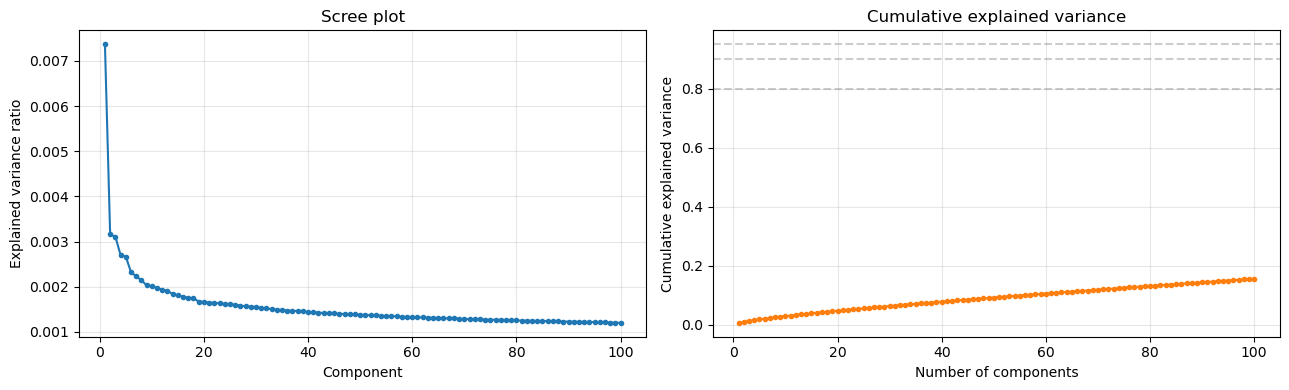

Selected k = 50 (captures 0.093 of variance)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, PCA_K_MAX + 1), explained_var, marker='o', markersize=3)
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot"); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, PCA_K_MAX + 1), cum_var, marker='o', markersize=3, color='C1')
for thresh in (0.80, 0.90, 0.95):
    axes[1].axhline(thresh, ls='--', alpha=0.4, color='gray')
    k_at = int(np.argmax(cum_var >= thresh)) + 1 if (cum_var >= thresh).any() else None
    if k_at:
        axes[1].axvline(k_at, ls=':', alpha=0.3, color='gray')
        axes[1].text(k_at + 1, thresh - 0.02, f"k={k_at} @ {int(thresh*100)}%", fontsize=9)
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# pick smallest k that captures over ~90% variance
target_var = 0.90
PCA_K = int(np.argmax(cum_var >= target_var)) + 1 if (cum_var >= target_var).any() else 50
PCA_K = min(PCA_K, 50)
print(f"Selected k = {PCA_K} (captures {cum_var[PCA_K-1]:.3f} of variance)")

In [24]:
#refitting PCA using the chosen k from above so the whole datasetb is transformed into its reduced form
pca = PCA(k=PCA_K, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_df)
reduced_df = pca_model.transform(scaled_df).select("release_name", "genre_index", "pca_features").cache()
print(f"Reduced feature dim: {reduced_df.first()['pca_features'].size}")
print(f"Row count: {reduced_df.count():,}")

Reduced feature dim: 50
Row count: 938,482


In [25]:
#start Kmeans clustering on the reduced dataset
#we can use silhouette scoree to see how well the clusters are identified , thats ther next chunk of code

n_clust = 19  # match number of genre buckets

kmeans = KMeans(featuresCol="pca_features", predictionCol="cluster",k=n_clust, seed=42, maxIter=20)
kmeans_model = kmeans.fit(reduced_df)
clustered_df = kmeans_model.transform(reduced_df).cache()

# silhouette score (squared Euclidean — Spark's default for ClusteringEvaluator)
silh_eval = ClusteringEvaluator(featuresCol="pca_features", predictionCol="cluster", metricName="silhouette", distanceMeasure="squaredEuclidean")
silh = silh_eval.evaluate(clustered_df)
print(f"Silhouette score (k={n_clust}): {silh:.4f}")

# cluster purity: in each cluster, what fraction belongs to the majority genre?
purity_df = (clustered_df.groupBy("cluster", "genre_index").count().withColumn("rank", F.row_number().over(Window.partitionBy("cluster").orderBy(F.col("count").desc()))))
top_per_cluster = purity_df.filter(F.col("rank") == 1).select("cluster", "count")
cluster_sizes = clustered_df.groupBy("cluster").count().withColumnRenamed("count", "cluster_size")
purity_joined = top_per_cluster.join(cluster_sizes, "cluster")
total_rows = clustered_df.count()
weighted_purity = (purity_joined.withColumn("contrib", F.col("count").cast("double") / F.lit(total_rows)).agg(F.sum("contrib")).first()[0])

print(f"Weighted cluster purity: {weighted_purity:.4f}")
print(f"(purity = fraction of points whose cluster's majority label matches their true label)")

Silhouette score (k=19): 0.3900
Weighted cluster purity: 0.3535
(purity = fraction of points whose cluster's majority label matches their true label)


  k=  5: silhouette = 0.7919
  k= 10: silhouette = 0.7789
  k= 15: silhouette = 0.4307
  k= 19: silhouette = 0.3900
  k= 25: silhouette = 0.3778
  k= 30: silhouette = 0.2869


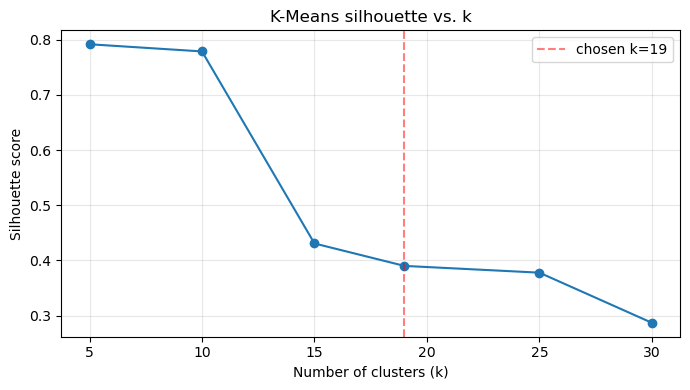

In [26]:
#sweep some k values to see if 19 is the best choice

k_values = [5, 10, 15, 19, 25, 30]
sweep_results = []
for k in k_values:
    km = KMeans(featuresCol="pca_features", predictionCol="cluster", k=k, seed=42, maxIter=20)
    km_model = km.fit(reduced_df)
    out = km_model.transform(reduced_df)
    s = silh_eval.evaluate(out)
    sweep_results.append((k, s))
    print(f"  k={k:3d}: silhouette = {s:.4f}")

ks, ss = zip(*sweep_results)
plt.figure(figsize=(7, 4))
plt.plot(ks, ss, marker='o')
plt.axvline(n_clust, ls='--', alpha=0.5, color='red', label=f'chosen k={n_clust}')
plt.xlabel("Number of clusters (k)"); plt.ylabel("Silhouette score")
plt.title("K-Means silhouette vs. k"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [31]:
#new xgboost model on the PCA reduced features

from xgboost.spark import SparkXGBClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train_xgb, test_xgb = reduced_df.select(
    "genre_index", 
    "pca_features"
).randomSplit([0.8, 0.2], seed=42)

xgb = SparkXGBClassifier(
    features_col="pca_features",
    label_col="genre_index",
    prediction_col="prediction",
    num_class=19,
    max_depth=5,
    n_estimators=50,
    learning_rate=0.3,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = xgb.fit(train_xgb)

xgb_preds = xgb_model.transform(test_xgb)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="genre_index",
    predictionCol="prediction",
    metricName="f1"
)

acc_eval = MulticlassClassificationEvaluator(
    labelCol="genre_index",
    predictionCol="prediction",
    metricName="accuracy"
)

print("PCA + XGBoost F1:", f1_eval.evaluate(xgb_preds))
print("PCA + XGBoost Accuracy:", acc_eval.evaluate(xgb_preds))

2026-05-26 22:46:12,072 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 1 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.3, 'max_depth': 5, 'subsample': 0.8, 'num_class': 19, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-05-26 22:48:07,308 INFO XGBoost-PySpark: _fit Finished xgboost training!


PCA + XGBoost F1: 0.6024433017008197
PCA + XGBoost Accuracy: 0.6149313635490276
